# Ripple Testing

In [2]:
# Loading/Import related packages
import sys
import os

#Usual suspects
import pandas as pd
import numpy as np
import json
import pickle as pkl
import matplotlib.pyplot as plt

#Extras for plotting
from matplotlib.patches import Patch

#Extra for typing
from collections import defaultdict

os.chdir("/Users/lizkal/Library/CloudStorage/SynologyDrive-Personal/PatientPlatform")


In [3]:
REPO_DIR  = os.path.abspath(os.getcwd())
data_dir = os.path.join(REPO_DIR, 'output')
results_dir = os.path.join(REPO_DIR, 'results')

from bend.src.ripple_analysis_functions_0110 import get_task_data, band_notch_sig, remove_spikes, plot_emg_with_movement, analyze_movement_snr, concat_movement

sys.path.insert(0, os.path.abspath("bend")) 
from bend.src.utils.select_windows import select_windows
from bend.src.utils.review_channels import review_channels

good_mask_path = "demo_good_mask.npy"
mask_path = "demo_mask.npy"
exclude_path = "demo_exclude.npy"

s1_folder = os.path.join(data_dir, 'emg_recording_Liz_session_001_20260930_144300_divided')


In [4]:
# This task used 3 tasks, each with 8 repitions
n_reps = 8
n_tasks = 3
movement_names = ['fist', 'fast_tripod', 'fast_finger_ext']

samp_freq = 2000
n_channels = 32

In [5]:
file_path =  os.path.join(REPO_DIR, "output/emg_recording_Liz_session_001_20260930_144300_divided/move_001.pkl")

result_pandas = pd.read_pickle(file_path)
print("Loaded data from:", file_path)
print(result_pandas.keys())
print(result_pandas['data'].shape)

Loaded data from: /Users/lizkal/Library/CloudStorage/SynologyDrive-Personal/PatientPlatform/output/emg_recording_Liz_session_001_20260930_144300_divided/move_001.pkl
dict_keys(['data', 'srate', 'phase', 'phase_occurrence', 'start_s', 'end_s', 'n_samples', 'duration_s', 'filtered', 'stream_type', 'trial_metadata'])
(32, 9340)


### Signal

##### Session 1

Note that fist and ft are super noisy. Using ffe for decomp.

In [6]:
s1_full = get_task_data(s1_folder, n_reps, movement_names, samp_freq, win = None)
s1_emg = s1_full['emg']
s1_metadata = s1_full['metadata']

print(s1_metadata.head())
print(s1_emg.ndim)

# isolating just middle 4 seconds, should be isometrical hold only. No start of movement.
"""
Maybe need to change window to cut off first N seconds because that is when the movement is initiated.
Isometrical hold for entire period, participant releases movement after movement duration period (ie first N seconds of rest)
"""
s1_win4 = get_task_data(s1_folder, n_reps, movement_names, samp_freq, win = 4)

   pose     phase  rep  duration  start_idx  end_idx
0  fist      prep    0     3.017          0     6034
1  fist  movement    0     4.670       6034    15374
2  fist      rest    0     7.006      15374    29386
3  fist      prep    1     3.003      29386    35392
4  fist  movement    1     4.670      35392    44732
2


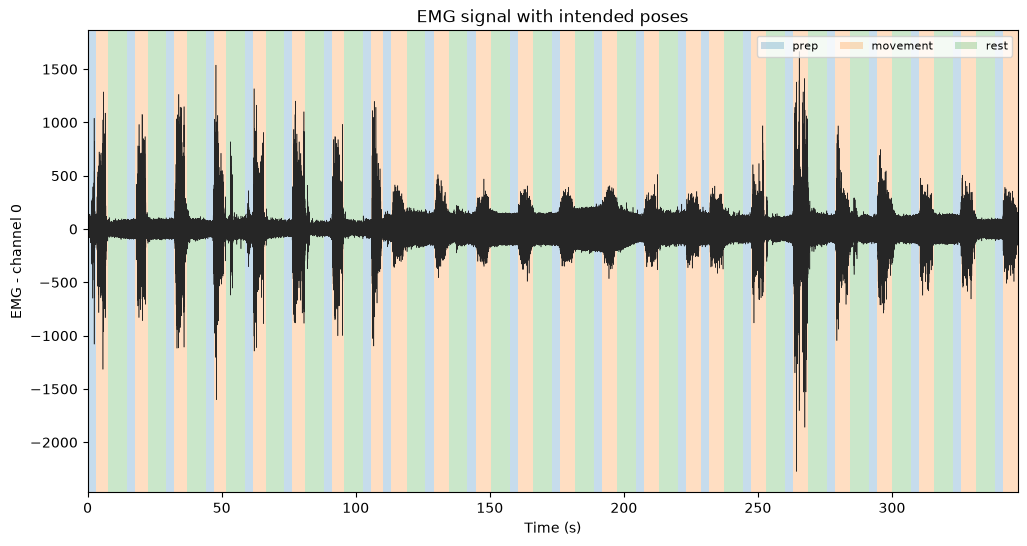

In [7]:
plot_emg_with_movement(s1_emg, 
                       s1_metadata['phase'],
                       s1_metadata['duration'], 
                       fs=samp_freq)
plt.show()



##### Session 2

# Preprocessing

##### Bandpass + Notch Filters

In [9]:
s1_emg_filt = band_notch_sig(s1_emg, fsamp = samp_freq)


#### Remove Spikes

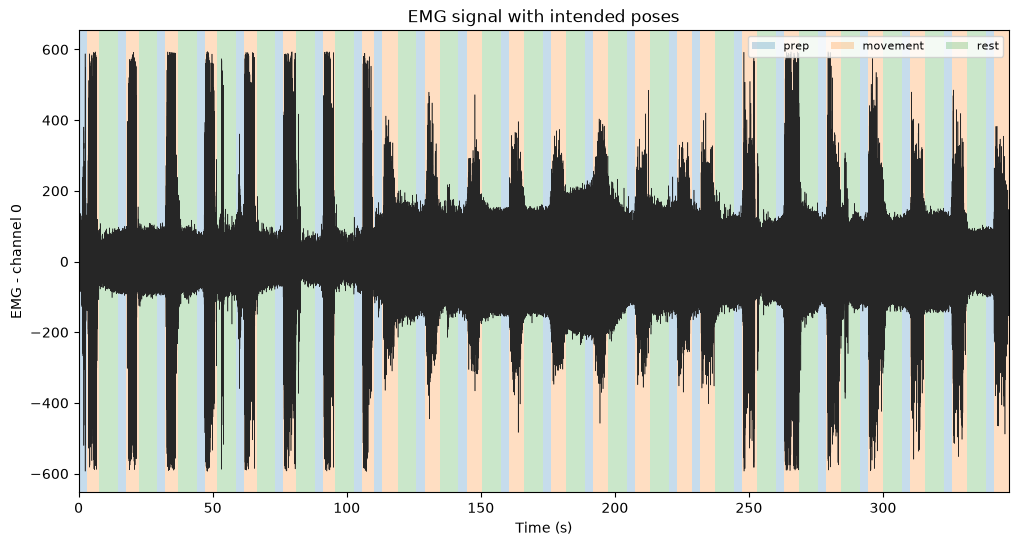

In [10]:
s1_full_clean, s1_full_spike_mask = remove_spikes(s1_emg_filt, threshold_std=5)

plot_emg_with_movement(s1_full_clean, 
                       s1_metadata['phase'],
                       s1_metadata['duration'], 
                       fs=samp_freq)
plt.show()

#### Concat movement signal

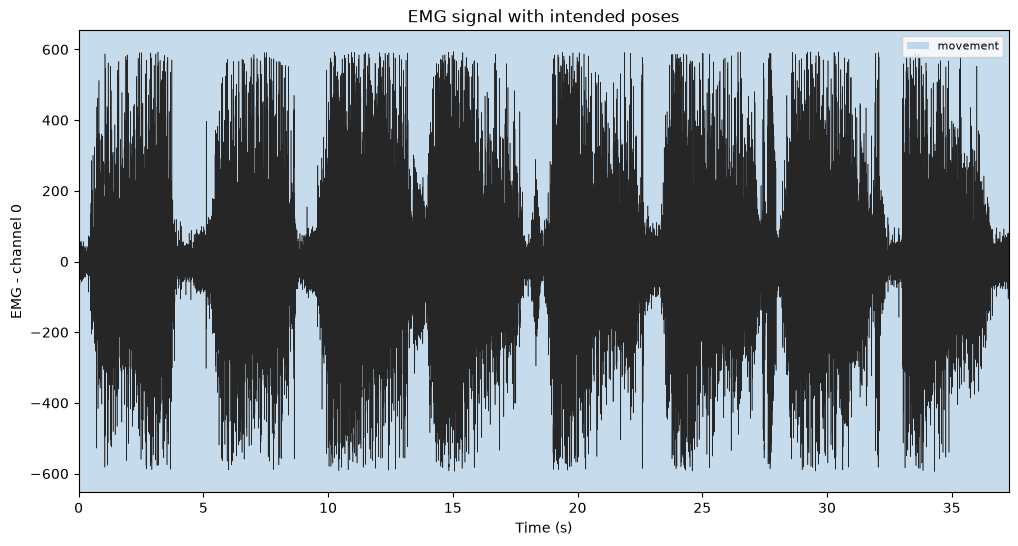

In [11]:
s1_fist_emg, s1_fist_meta = concat_movement(
    emg_arr=s1_full_clean,
    metadata=s1_metadata,
    pose='fist',
    phase='movement',
    fs=samp_freq
)

plot_emg_with_movement(s1_fist_emg, 
                       s1_fist_meta['phase'],
                       s1_fist_meta['duration'], 
                       fs=samp_freq)
plt.show()

#### Review Channels

In [20]:
%matplotlib qt

review_channels(s1_fist_emg, 
                good_mask_path, fs=samp_freq, label="demo")

seed: auto RMS-outlier mask (32/32 good, bad [])
SAVED: demo_good_mask.npy, 32/32 good


#### Select windows

In [21]:
select_windows(s1_fist_emg, fs=samp_freq, mask_path=mask_path, exclude_path=exclude_path, label="demo")

SAVED: 9 bouts -> demo_mask.npy


##### Combine channels + windows

In [22]:
def load_bool(path, n, default):
    if not os.path.exists(path):
        return default
    m = np.load(path).astype(bool)
    return m[:n] if m.shape[0] >= n else np.pad(m, (0, n - m.shape[0]))

n_ch, n_samp = s1_fist_emg.shape
good = load_bool(good_mask_path, n_ch, np.ones(n_ch, bool))
mask = load_bool(mask_path, n_samp, np.zeros(n_samp, bool))
mask &= ~load_bool(exclude_path, n_samp, np.zeros(n_samp, bool))

selected = s1_fist_emg[good][:, mask]
print(f"good channels: {good.sum()}/{n_ch}")
print(f"kept samples: {mask.sum()}/{n_samp} ({mask.sum() / samp_freq:.1f}s)")
print(f"selected: {selected.shape}")

good channels: 32/32
kept samples: 61005/74566 (30.5s)
selected: (32, 61005)


In [23]:
%matplotlib inline

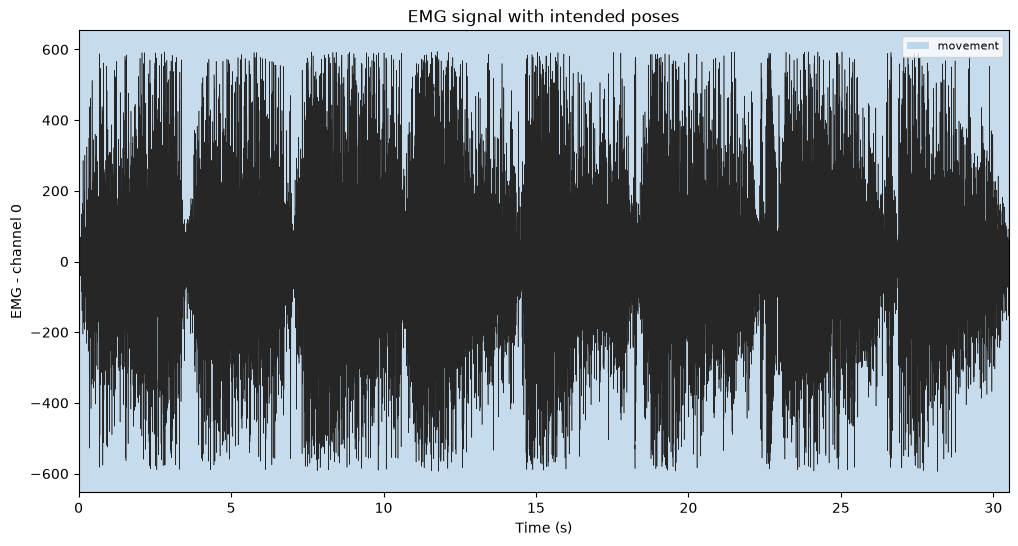

In [24]:

plot_emg_with_movement(selected, 
                       s1_fist_meta['phase'],
                       s1_fist_meta['duration'], 
                       fs=samp_freq)
plt.show()

# CBSS

In [14]:
# Load the baseline configuration
with open(os.path.join(REPO_DIR, 'bend', 'src', 'configs', 'cbss.json')) as f:
    cbss_config = json.load(f)['Config']

# The JSON stores disabled options as the string "None", turn them back into real None
cbss_config = {k: (None if v == "None" else v) for k, v in cbss_config.items()}

# Fewer iterations than the config asks for, again just to keep the notebook quick
# cbss_config['opt_function_exp'] = 2

print(json.dumps(cbss_config, indent=2))

{
  "start_time": 0,
  "end_time": -1,
  "sampling_frequency": 2000,
  "bandpass": null,
  "bandpass_order": 2,
  "notch_frequency": 50,
  "notch_n_harmonics": 3,
  "notch_order": 2,
  "notch_width": 1,
  "ext_fact": 16,
  "whitening_method": "ZCA",
  "whitening_reg": "auto",
  "ica_n_iter": 100,
  "opt_initalization": "random",
  "opt_function_exp": 3,
  "opt_max_iter": 100,
  "opt_tol": 0.0001,
  "source_deflation": "gram-schmidt",
  "peel_off": true,
  "fr_peeloff": false,
  "cluster_method": "kmeans",
  "random_seed": 1909,
  "refinement_loop": true,
  "sil_th": 0.85,
  "cov_th": 0.3,
  "verbose_mode": false
}


In [16]:
cbss_dir = "/Users/lizkal/Library/CloudStorage/SynologyDrive-Personal/MotorUnitSuite/src/muniverse/algorithms"

from bend.src.muniverse.algorithms.cbss import CBSS


In [17]:

decomposer = CBSS(**cbss_config)

sources_cbss, spikes_cbss, sil_cbss, filters_cbss, Z_cbss, centroids_cbss = decomposer.decompose(
    s1_fist_emg, fsamp=samp_freq
)

# all rejected, very high CoVs, 1.507, perhaps because of too much noise??

[INFO] Extending signals by factor 16...
Refinement loop for source 0 (initial Sil: 0.734, CoV: 2.249, Spikes: 101)
Refinement loop for source 1 (initial Sil: 0.741, CoV: 2.276, Spikes: 105)
Refinement loop for source 2 (initial Sil: 0.725, CoV: 2.356, Spikes: 112)
Refinement loop for source 3 (initial Sil: 0.770, CoV: 2.002, Spikes: 72)
Refinement loop for source 4 (initial Sil: 0.809, CoV: 1.998, Spikes: 76)
Refinement loop for source 5 (initial Sil: 0.779, CoV: 2.098, Spikes: 86)
Refinement loop for source 6 (initial Sil: 0.758, CoV: 1.958, Spikes: 85)
Refinement loop for source 7 (initial Sil: 0.733, CoV: 1.982, Spikes: 74)
Refinement loop for source 8 (initial Sil: 0.744, CoV: 2.300, Spikes: 91)
Refinement loop for source 9 (initial Sil: 0.785, CoV: 1.832, Spikes: 74)
Refinement loop for source 10 (initial Sil: 0.766, CoV: 1.752, Spikes: 53)
Refinement loop for source 11 (initial Sil: 0.753, CoV: 2.135, Spikes: 79)
Refinement loop for source 12 (initial Sil: 0.773, CoV: 1.820, Spi

In [18]:
print(f"Sources coming out of the loop: {sources_cbss.shape[0]}")


Sources coming out of the loop: 0
